# Profile likelihood for discrete-time LTI: KF vs Taylor-KF vs PF

This **deep dive** builds a **profile likelihood** for a single parameter (one entry of the $A$ matrix) in a discrete-time LTI system. All other parameters are **known** (no biases). Controls are simulated i.i.d. from $\mathcal{N}(0,1)$. We compare the profile log-likelihood computed with:

- **KF** (exact Kalman filter, dynamax)
- **taylor_kf** (Taylor-linearized Kalman filter, cuthbert)
- **PF** (bootstrap particle filter, cuthbert)

**Setup:** 2 states, 1 control, 1 output. We learn $\alpha = A_{0,0}$; $A_{1,1}$ and $B$, $H$, $R$, $Q$ are fixed.

## Imports and config

In [1]:
import jax
import jax.numpy as jnp
import jax.random as jr
import numpyro
import numpyro.distributions as dist
from numpyro.infer import Predictive

import dynestyx as dsx
from dynestyx import (
    Context,
    Condition,
    DiscreteTimeSimulator,
    DynamicalModel,
    LinearGaussianStateEvolution,
    LinearGaussianObservation,
    Trajectory,
    FilterBasedMarginalLogLikelihood
)

import matplotlib.pyplot as plt
import numpy as np

# Dimensions: 2 states, 1 control, 1 output
state_dim = 2
control_dim = 1
observation_dim = 1

## LTI model: one learned parameter $\alpha = A_{0,0}$, no biases

We set $A = \begin{bmatrix} \alpha & 0 \\ 0 & 0.8 \end{bmatrix}$, $B$, $H$, $R$, $Q$ fixed. Biases $b$, $d$ are zero.

In [2]:
def lti_one_param_model():
    """Discrete-time LTI: only alpha = A[0,0] is sampled; all else fixed, no biases."""
    alpha = numpyro.sample("alpha", dist.Uniform(-0.7, 0.7))
    A = jnp.array([[alpha, 0.0], [0.0, 0.8]])
    Q = 0.1 * jnp.eye(state_dim)
    H = jnp.array([[1.0, 0.0]])
    R = jnp.array([[0.5**2]])
    initial_mean = jnp.zeros(state_dim)
    initial_cov = jnp.eye(state_dim)
    B = jnp.array([[0.1], [0.0]])
    D = jnp.array([[0.01]])
    # No biases
    b = jnp.zeros(state_dim)
    d = jnp.zeros(observation_dim)
    dynamics = DynamicalModel(
        initial_condition=dist.MultivariateNormal(initial_mean, initial_cov),
        state_evolution=LinearGaussianStateEvolution(A=A, B=B, bias=b, cov=Q),
        observation_model=LinearGaussianObservation(H=H, D=D, bias=d, R=R),
        state_dim=state_dim,
        observation_dim=observation_dim,
        control_dim=control_dim,
    )
    dsx.sample("f", dynamics)

## True parameter, observation times, and controls $u_t \sim \mathcal{N}(0,1)$

In [3]:
true_alpha = 0.4
obs_times = jnp.arange(0.0, 1000.0, 1.0)
T = len(obs_times)

key = jr.PRNGKey(42)
key_ctrl, key_data = jr.split(key)
# Controls i.i.d. N(0,1)
ctrl_values = jr.normal(key_ctrl, shape=(T, control_dim))
control_trajectory = Trajectory(times=obs_times, values=ctrl_values)

print("True alpha:", true_alpha)
print("Observation times length:", T)
print("Controls shape:", ctrl_values.shape)

True alpha: 0.4
Observation times length: 1000
Controls shape: (1000, 1)


## Generate synthetic observations

Simulate the model with true $\alpha$ and the control trajectory to get $y_{1:T}$.

In [4]:
context_for_sim = Context(
    observations=Trajectory(times=obs_times),
    controls=control_trajectory,
)
predictive = Predictive(
    lti_one_param_model,
    params={"alpha": jnp.array(true_alpha)},
    num_samples=1,
    exclude_deterministic=False,
)

with DiscreteTimeSimulator():
    with Condition(context_for_sim):
        synthetic = predictive(key_data)

obs_values = synthetic["observations"].squeeze(0)
observation_trajectory = Trajectory(times=obs_times, values=obs_values)
context = Context(
    observations=observation_trajectory,
    controls=control_trajectory,
)
print("Observations shape:", obs_values.shape)

Observations shape: (1000, 1)


## Profile log-likelihood

For each filter type (KF, taylor_kf, PF), we compute $\log p(y_{1:T} \mid \alpha)$ by running `Predictive` with `params={"alpha": alpha}`. The marginal log-likelihood is the `f_marginal_loglik` deterministic site. We `vmap` over the grid of $\alpha$ values.

**Note:** The PF profile is stochastic (one random key per run). Re-run the PF cell with a different key to see variability. KF and taylor_kf are deterministic for this LTI model.

In [5]:
alpha_min, alpha_max = -0.6, 0.6
n_grid = 61
alpha_grid = jnp.linspace(alpha_min, alpha_max, n_grid)


def make_model(filter_type):
    """Build data-conditioned model with given filter type."""
    kwargs = {"filter_type": filter_type}

    def model():
        with FilterBasedMarginalLogLikelihood(filter_type=filter_type, n_filter_particles=2000):
            with Condition(context):
                return lti_one_param_model()

    return model


def get_marginal_loglik(alpha_val, key, filter_type):
    """Run Predictive with fixed alpha; return f_marginal_loglik site."""
    model = make_model(filter_type)
    pred = Predictive(
        model,
        params={"alpha": jnp.array(alpha_val)},
        num_samples=1,
        exclude_deterministic=False,
    )
    out = pred(key)
    return out["f_marginal_loglik"].squeeze()


def profile_log_likelihood(filter_type, alpha_vals, key=jr.PRNGKey(0)):
    """Profile log p(y | alpha) via vmap over Predictive + f_marginal_loglik."""
    keys = jr.split(key, len(alpha_vals))
    return jax.vmap(
        lambda a, k: get_marginal_loglik(a, k, filter_type),
        in_axes=(0, 0),
    )(alpha_vals, keys)

In [6]:
profile_kf = profile_log_likelihood("kf", alpha_grid)
profile_taylor_kf = profile_log_likelihood("taylor_kf", alpha_grid)
profile_pf = profile_log_likelihood("pf", alpha_grid)

print("KF       max profile ll: ", float(jnp.nanmax(profile_kf)))
print("taylor_kf max profile ll:", float(jnp.nanmax(profile_taylor_kf)))
print("PF       max profile ll: ", float(jnp.nanmax(profile_pf)))

KF       max profile ll:  -907.543701171875
taylor_kf max profile ll: -907.543701171875
PF       max profile ll:  -912.537109375


## Plot profile log-likelihoods

All three filters should peak near the true $\alpha = 0.4$. KF is exact for this LTI; taylor_kf is a linearization; PF is a Monte Carlo approximation.

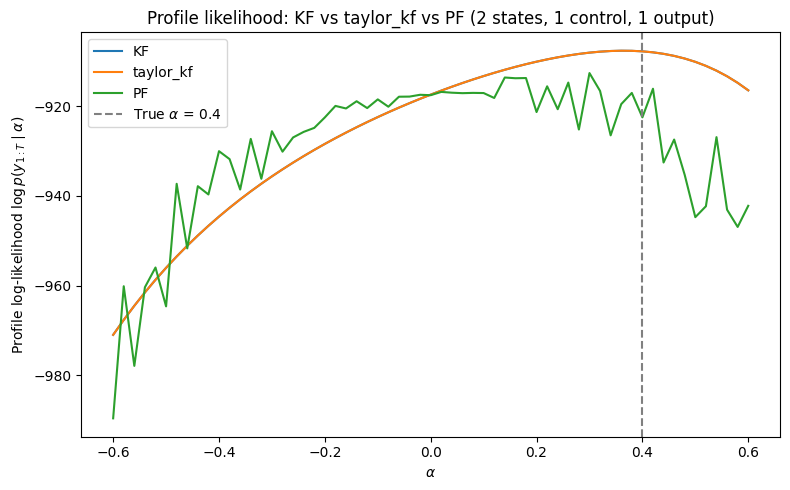

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ax.plot(np.array(alpha_grid), np.array(profile_kf), label="KF", color="C0")
ax.plot(np.array(alpha_grid), np.array(profile_taylor_kf), label="taylor_kf", color="C1")
ax.plot(np.array(alpha_grid), np.array(profile_pf), label="PF", color="C2")
ax.axvline(true_alpha, color="gray", linestyle="--", label=f"True $\\alpha$ = {true_alpha}")
ax.set_xlabel("$\\alpha$")
ax.set_ylabel("Profile log-likelihood $\\log p(y_{1:T} \\mid \\alpha)$")
ax.legend()
ax.set_title("Profile likelihood: KF vs taylor_kf vs PF (2 states, 1 control, 1 output)")
plt.tight_layout()
plt.show()